# DATA PREPROCESSING 

Loading our necessary modules in which we will use to clean and preprocess the data


In [1]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

Loading our dataset as well as checking the shape, duplicates and missing values from our dataset

In [2]:
df = pd.read_csv(r'synthetic_heart_disease_dataset.csv')

print(f"Shape:         {df.shape}")
print(f"Duplicates:    {df.duplicated().sum()}")
print(f"Missing (NaN): {df.isnull().sum().sum()}")

df.head(5)

Shape:         (50000, 21)
Duplicates:    0
Missing (NaN): 20109


,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,...,1,0,0,0,164,67,108,116,220,1


In [3]:
df.isnull().sum()

Age                          0
Gender                       0
Weight                       0
Height                       0
BMI                          0
Smoking                      0
Alcohol_Intake           20109
Physical_Activity            0
Diet                         0
Stress_Level                 0
Hypertension                 0
Diabetes                     0
Hyperlipidemia               0
Family_History               0
Previous_Heart_Attack        0
Systolic_BP                  0
Diastolic_BP                 0
Heart_Rate                   0
Blood_Sugar_Fasting          0
Cholesterol_Total            0
Heart_Disease                0
dtype: int64

In [4]:
df.duplicated().sum()


np.int64(0)

Dropping the roles to which the missing values are found

In [5]:
df=df.dropna(subset=['Alcohol_Intake'])

Checking for for unique text

In [6]:
print(df['Gender'].unique())
print(df['Smoking'].unique())
print(df['Physical_Activity'].unique())
print(df['Diet'].unique())
print(df['Stress_Level'].unique())
print(df['Alcohol_Intake'].unique())

<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
<ArrowStringArray>
['Never', 'Current', 'Former']
Length: 3, dtype: str
<ArrowStringArray>
['Active', 'Moderate', 'Sedentary']
Length: 3, dtype: str
<ArrowStringArray>
['Average', 'Unhealthy', 'Healthy']
Length: 3, dtype: str
<ArrowStringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str
<ArrowStringArray>
['Low', 'Moderate', 'High']
Length: 3, dtype: str


Converting those unique text into numbers because the machine cannnot understand text

In [7]:
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df['Smoking'] = df['Smoking'].map({'Never':2, 'Current':1, 'Former':0})
df['Physical_Activity'] = df['Physical_Activity'].map({'Sedentary':2,'Active':1,'Moderate':0})
df['Diet'] = df['Diet'].map({'Healthy':2,'Average':1,'Unhealthy':0})
df['Stress_Level'] = df['Stress_Level'].map({'Medium':2,'High':1,'Low':0})
df['Alcohol_Intake'] = df['Alcohol_Intake'].map({'Low':0,'Moderate':1,'High':2})

In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 29891 entries, 1 to 49999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    29891 non-null  int64  
 1   Gender                 29891 non-null  int64  
 2   Weight                 29891 non-null  int64  
 3   Height                 29891 non-null  int64  
 4   BMI                    29891 non-null  float64
 5   Smoking                29891 non-null  int64  
 6   Alcohol_Intake         29891 non-null  int64  
 7   Physical_Activity      29891 non-null  int64  
 8   Diet                   29891 non-null  int64  
 9   Stress_Level           29891 non-null  int64  
 10  Hypertension           29891 non-null  int64  
 11  Diabetes               29891 non-null  int64  
 12  Hyperlipidemia         29891 non-null  int64  
 13  Family_History         29891 non-null  int64  
 14  Previous_Heart_Attack  29891 non-null  int64  
 15  Systolic_BP       

Checking for class balance to see the number of heart and non heart disease patients 

Heart_Disease
0    16024
1    13867
Name: count, dtype: int64
No Heart Disease: 16024  (53.6%)
Heart Disease:    13867  (46.4%)


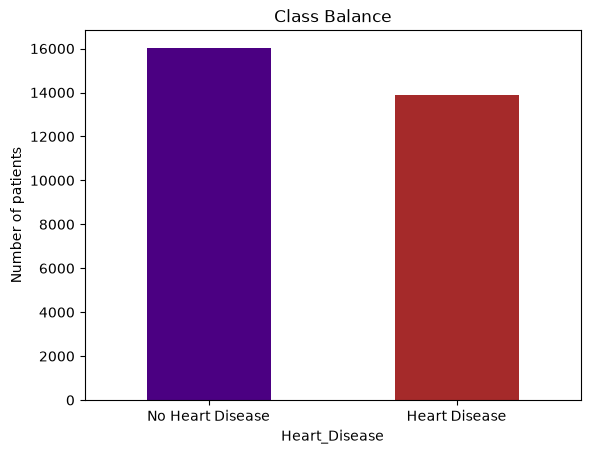

In [9]:
counts = df['Heart_Disease'].value_counts()
print(counts)

print(f"No Heart Disease: {counts[0]}  ({counts[0] / len(df):.1%})")
print(f"Heart Disease:    {counts[1]}  ({counts[1] / len(df):.1%})")

counts.plot(kind='bar', color=['indigo', 'brown'])
plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'], rotation=0)
plt.title('Class Balance')
plt.ylabel('Number of patients')
plt.show()

Dropping the columns weight and height because bmi column is present and to calculate BMI is height^2/weight

In [10]:
df=df.drop('Weight',axis=1)
df = df.drop('Height', axis=1)

In [11]:
df

,Age,Gender,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
1,35,0,33.0,2,0,1,1,1,1,0,1,1,0,111,72,60,145,206,0
3,75,1,37.4,2,1,0,1,0,0,0,1,0,0,171,92,109,105,290,1
6,67,1,22.3,2,1,0,0,0,1,0,0,0,0,153,82,85,145,156,1
9,74,1,35.7,1,0,0,0,0,0,0,0,0,0,114,69,87,117,195,0
10,38,1,34.7,1,2,2,1,0,0,0,0,1,0,106,102,67,116,284,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49993,39,0,18.1,2,2,0,1,2,0,0,0,0,0,111,105,80,141,160,0
49996,53,1,35.8,2,0,0,2,0,0,0,1,0,0,141,96,70,148,252,0
49997,38,0,32.3,0,0,0,0,0,0,0,0,0,0,178,94,90,75,235,0
49998,68,1,18.6,2,2,0,1,2,0,0,0,0,0,118,110,106,113,177,0


Comparing heart disease and no heart disease features with the rest of the features and see where most cases fall

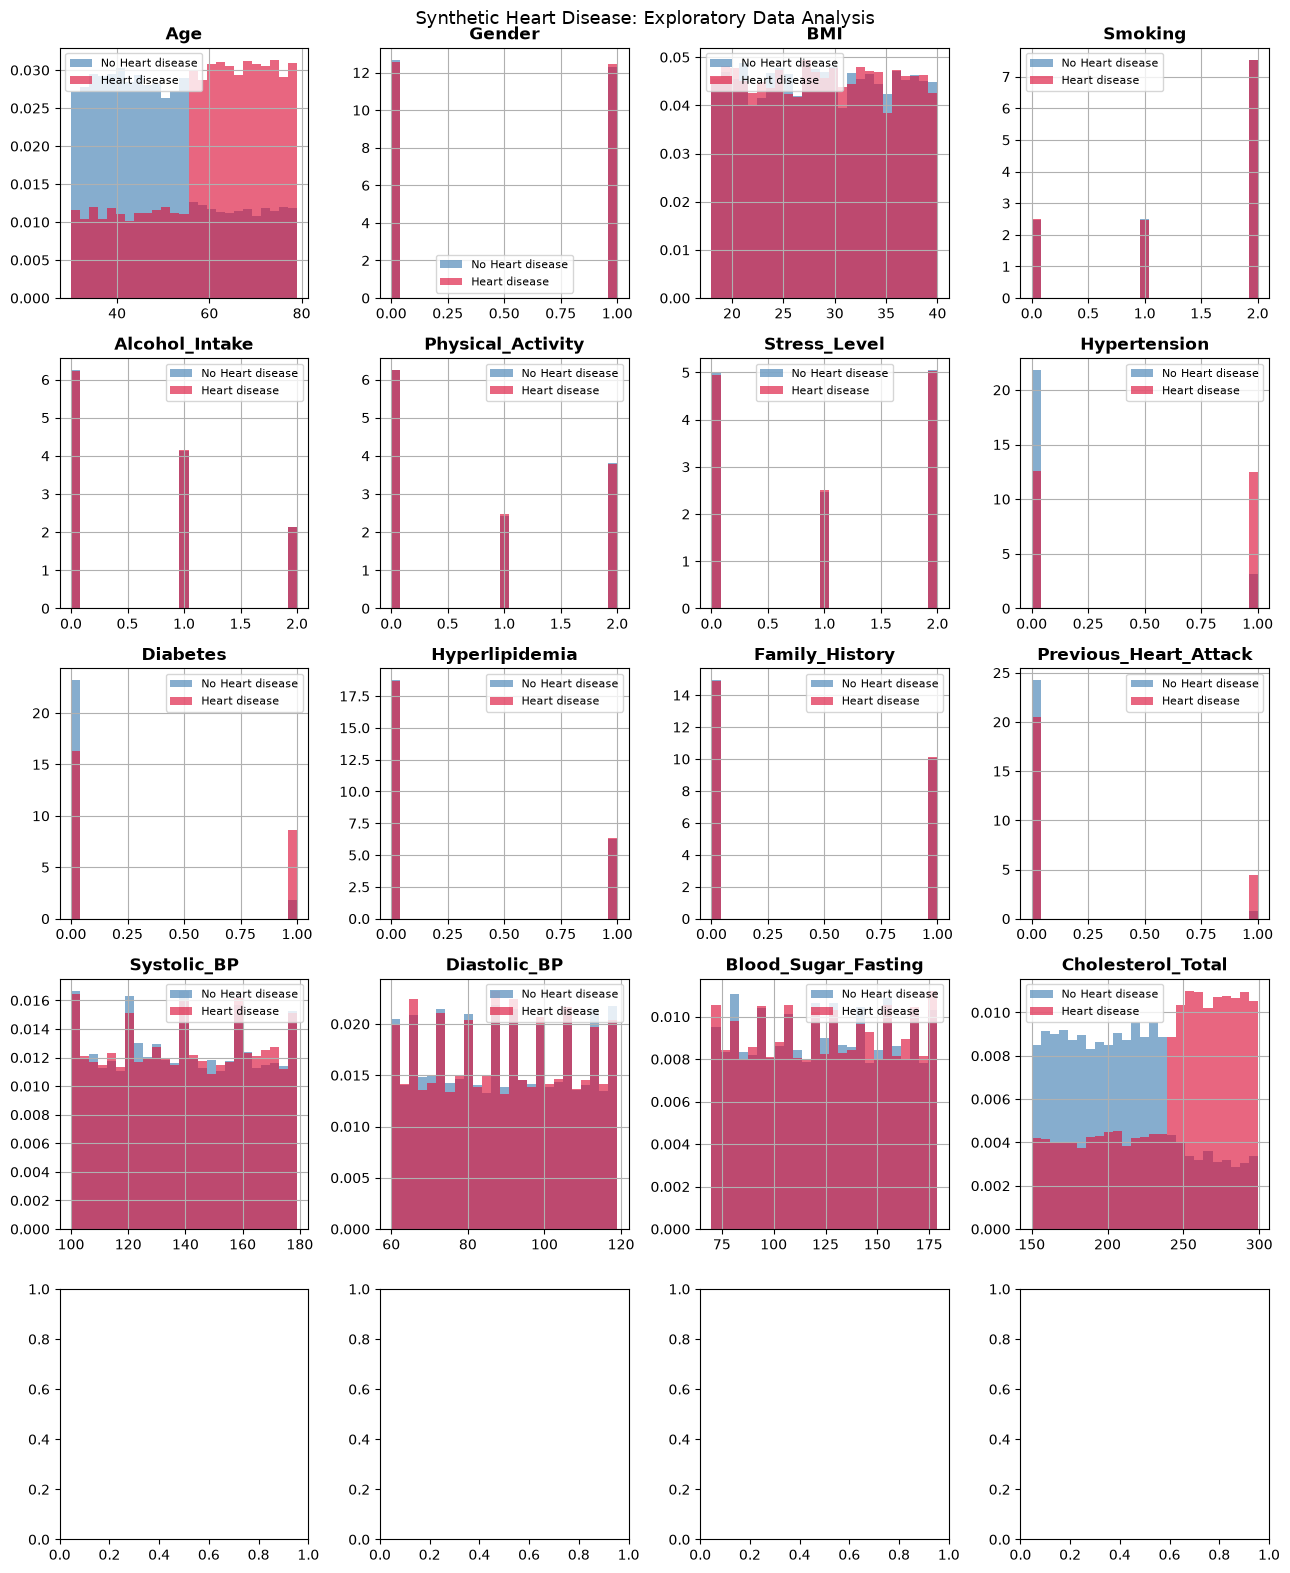

In [12]:
FEATURES = ['Age','Gender','BMI','Smoking','Alcohol_Intake',
            'Physical_Activity','Stress_Level','Hypertension',
            'Diabetes','Hyperlipidemia','Family_History','Previous_Heart_Attack',
            'Systolic_BP','Diastolic_BP','Blood_Sugar_Fasting','Cholesterol_Total']

fig, axes = plt.subplots(5, 4, figsize=(13, 16))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    df[df['Heart_Disease'] == 0][col].hist(ax=axes[i], bins=25, alpha=0.65,
                                      color='steelblue', label='No Heart disease', density=True)
    df[df['Heart_Disease'] == 1][col].hist(ax=axes[i], bins=25, alpha=0.65,
                                      color='crimson', label='Heart disease', density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)


plt.suptitle('Synthetic Heart Disease: Exploratory Data Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('Synthetic_Heart_Disease.png', dpi=150, bbox_inches='tight')
plt.show()

Correlating our features and seeing how all the features correlate with other features 

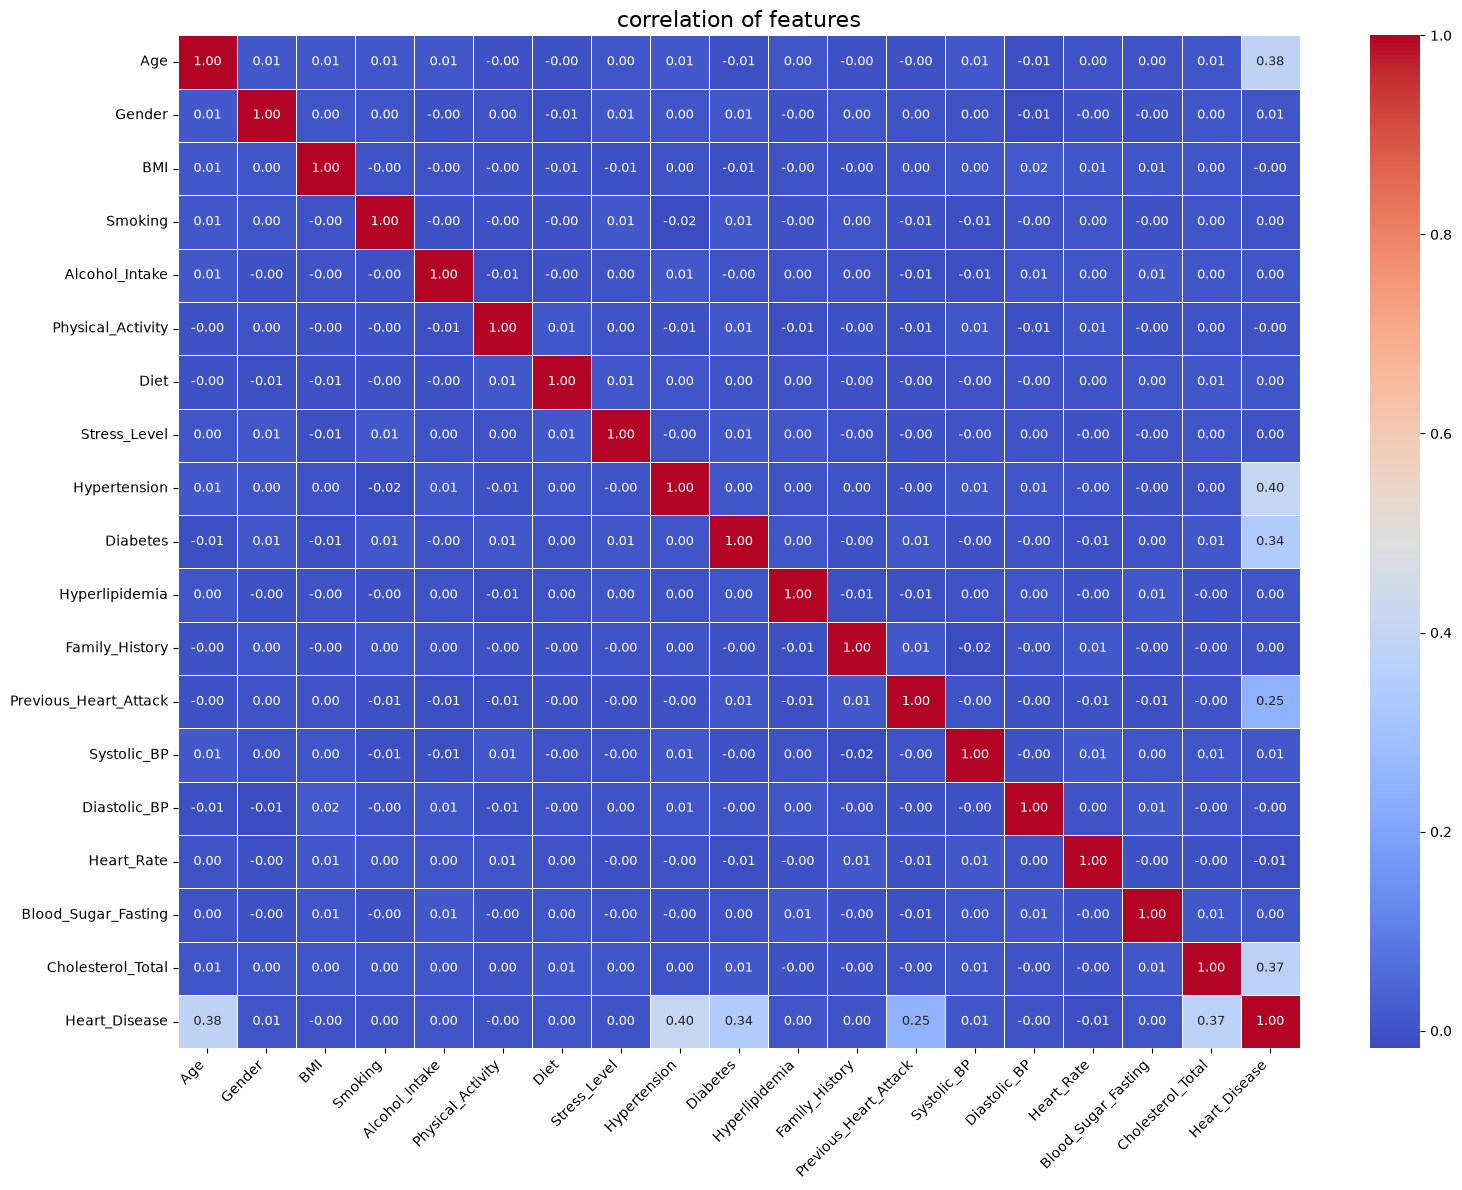

In [13]:
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',linewidths=0.5, annot_kws={'size': 9})
# axes[8].set_title('Correlations', fontweight='bold')
plt.title('correlation of features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Checking for zero valuea cuz features like systolic and diastolic bp as well as bmi cannot have zero as values cuz its either a missing value or impossible 

In [14]:
ZERO_AS_MISSING = ['BMI',
            'Physical_Activity','Stress_Level','Hypertension',
            'Diabetes',
            'Systolic_BP','Diastolic_BP','Cholesterol_Total']

print(f"{'Column':<20} {'Zero count':>10}  {'% of rows':>10}")
print("-" * 44)
for col in ZERO_AS_MISSING:
    n_zero = (df[col] == 0).sum()
    print(f"{col:<20} {n_zero:>10}  {n_zero / len(df) * 100:>9.1f}%")


Column               Zero count   % of rows
--------------------------------------------
BMI                           0        0.0%
Physical_Activity         14941       50.0%
Stress_Level              11878       39.7%
Hypertension              20952       70.1%
Diabetes                  23914       80.0%
Systolic_BP                   0        0.0%
Diastolic_BP                  0        0.0%
Cholesterol_Total             0        0.0%


In [15]:
df_clean=df.copy()

Splitting our data into training set, testing set and validation set

In [16]:
X = df_clean[FEATURES].values.astype(np.float32)
y = df_clean['Heart_Disease'].values.astype(np.float32)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.221, stratify=y_temp, random_state=RANDOM_SEED)

print(f"Train: {len(X_train):>4} rows  ({y_train.mean():.1%} positive)")
print(f"Val:   {len(X_val):>4} rows  ({y_val.mean():.1%} positive)")
print(f"Test:  {len(X_test):>4} rows  ({y_test.mean():.1%} positive)")

X

Train: 18627 rows  (46.4% positive)
Val:   5285 rows  (46.4% positive)
Test:  5979 rows  (46.4% positive)


array([[ 35. ,   0. ,  33. , ...,  72. , 145. , 206. ],
       [ 75. ,   1. ,  37.4, ...,  92. , 105. , 290. ],
       [ 67. ,   1. ,  22.3, ...,  82. , 145. , 156. ],
       ...,
       [ 38. ,   0. ,  32.3, ...,  94. ,  75. , 235. ],
       [ 68. ,   1. ,  18.6, ..., 110. , 113. , 177. ],
       [ 53. ,   0. ,  21.7, ..., 111. , 172. , 280. ]],
      shape=(29891, 16), dtype=float32)

Scaling the values of the data so as to avoid outliers  

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling done. Example, first row before and after:")
print("Before:", X_train[0][:5])
print("After: ", X_train_scaled[0][:5].round(2))

Scaling done. Example, first row before and after:
Before: [49.  1. 37.  2.  0.]
After:  [-0.38  1.01  1.27  0.75 -0.9 ]


Dropping the heart disease or output columns from the data so that during training the model does not cram the answers 

In [18]:
import json

# --- CSV: scaled features + target, one file per split ---
train_df = pd.DataFrame(X_train_scaled, columns=FEATURES)
train_df['Heart_Disease'] = y_train

val_df = pd.DataFrame(X_val_scaled, columns=FEATURES)
val_df['Heart_Disease'] = y_val

test_df = pd.DataFrame(X_test_scaled, columns=FEATURES)
test_df['Heart_Disease'] = y_test

train_df.to_csv('heart_disease_train.csv', index=False)
val_df.to_csv('heart_disease_val.csv', index=False)
test_df.to_csv('heart_disease_test.csv', index=False)

print("Saved heart_disease_train.csv", train_df.shape)
print("Saved heart_disease_val.csv  ", val_df.shape)
print("Saved heart_disease_test.csv ", test_df.shape)

Saved heart_disease_train.csv (18627, 17)
Saved heart_disease_val.csv   (5285, 17)
Saved heart_disease_test.csv  (5979, 17)


Saving our scaler mean, feature columns and scaler scale to be used when inputing new patients so that they will be scaled in the same manner and scale range 

In [19]:
# --- JSON: feature names, medians, and the scaler's numbers ---
metadata = {
    'feature_cols': FEATURES,
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
}

with open('heart_disease_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved heart_disease_metadata.json")


Saved heart_disease_metadata.json


In [20]:
# --- PKL: one convenience bundle with everything, including the scaler object ---
prepared_data = {
    'X_train': X_train_scaled,
    'X_val': X_val_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    'scaler': scaler,
    'feature_cols': FEATURES,
}

with open('heart_disease_prepared.pkl', 'wb') as f:
    pickle.dump(prepared_data, f)

print("Saved heart_disease_prepared.pkl")


Saved heart_disease_prepared.pkl
